<a href="https://colab.research.google.com/github/amineabidi7/justice_climatic/blob/main/Justice__climatique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import requests, io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# ── Dataset 1 : Émissions CO2 (Our World in Data) ──────────────────────
url_co2 = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"
co2 = pd.read_csv(url_co2)
print(f"CO2     : {co2.shape}  →  {co2['country'].nunique()} pays, {co2['year'].min()}–{co2['year'].max()}")

# ── Dataset 2 : Énergie (Our World in Data) ─────────────────────────────
url_nrj = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
nrj = pd.read_csv(url_nrj)
print(f"Énergie : {nrj.shape}  →  {nrj['country'].nunique()} pays")

# ── Dataset 3 : IDH (UNDP) — même URL que le PDF, contournement 403 ─────
url_hdi = ("https://hdr.undp.org/sites/default/files/2023-24_HDR/"
           "HDR23-24_Composite_indices_complete_time_series.csv")

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
response = requests.get(url_hdi, headers=headers)
hdi = pd.read_csv(io.StringIO(response.text), encoding='latin1')

print(f"HDI : {hdi.shape}  →  {hdi['country'].nunique()} pays")
print(hdi.head(3))

# ── Dataset 4 : Gapminder (PIB, espérance de vie, population) ───────────
url_gap = "https://raw.githubusercontent.com/plotly/datasets/master/gapminder_unfiltered.csv"
gap = pd.read_csv(url_gap)
print(f"Gapminder: {gap.shape}  →  {gap['country'].nunique()} pays, {gap['year'].min()}–{gap['year'].max()}")

CO2     : (50411, 79)  →  254 pays, 1750–2024
Énergie : (23232, 130)  →  314 pays
HDI : (206, 1076)  →  206 pays
  iso3      country hdicode region  hdi_rank_2022  hdi_1990  hdi_1991  \
0  AFG  Afghanistan     Low     SA         182.00      0.28      0.29   
1  ALB      Albania    High    ECA          74.00      0.65      0.63   
2  DZA      Algeria    High     AS          93.00      0.59      0.60   

   hdi_1992  hdi_1993  hdi_1994  hdi_1995  hdi_1996  hdi_1997  hdi_1998  \
0      0.30      0.31      0.30      0.32      0.33      0.33      0.33   
1      0.62      0.62      0.62      0.63      0.64      0.64      0.66   
2      0.60      0.60      0.60      0.61      0.62      0.63      0.64   

   hdi_1999  hdi_2000  hdi_2001  hdi_2002  hdi_2003  hdi_2004  hdi_2005  \
0      0.34      0.34      0.34      0.37      0.38      0.40      0.40   
1      0.67      0.68      0.69      0.69      0.70      0.71      0.72   
2      0.64      0.65      0.66      0.67      0.68      0.68      0

In [ ]:
# On garde uniquement l'année 2019

ANNEE = 2019

# ── CO2 : variables d'émissions ─────────────────────────────────────────
co2_sel = co2[co2['year'] == ANNEE][[
    'country', 'iso_code',
    'co2',              # émissions totales (millions de tonnes)
    'co2_per_capita',   # émissions par habitant (tonnes/personne)
    'coal_co2',         # part du charbon
    'oil_co2',          # part du pétrole
    'gas_co2',          # part du gaz
    'cumulative_co2',   # émissions cumulées historiques
    'ghg_per_capita',   # tous gaz à effet de serre / habitant
]].copy()

# ── Énergie : mix énergétique ────────────────────────────────────────────
nrj_sel = nrj[nrj['year'] == ANNEE][[
    'country', 'iso_code',
    'coal_share_energy',        # % charbon dans le mix
    'gas_share_energy',         # % gaz
    'oil_share_energy',         # % pétrole
    'renewables_share_energy',  # % renouvelables
    'fossil_share_energy',      # % fossiles total
    'energy_per_capita',        # consommation énergie / habitant
]].copy()

# ── HDI : développement humain ───────────────────────────────────────────
# On garde l'IDH 2019 et la catégorie (Low/Medium/High/Very High)
hdi_sel = hdi[['iso3', 'country', 'hdicode', 'hdi_2019']].copy()
hdi_sel.columns = ['iso_code', 'country_hdi', 'hdicode', 'hdi']

# ── Gapminder : PIB et démographie ──────────────────────────────────────
gap_sel = gap[gap['year'] == 2007][[  # Gapminder s'arrête en 2007
    'country', 'continent',
    'gdpPercap',    # PIB par habitant (dollars)
    'lifeExp',      # espérance de vie
    'pop',          # population
]].copy()

print("Sélection faite ")
print(f"  CO2     : {co2_sel.shape}")
print(f"  Énergie : {nrj_sel.shape}")
print(f"  HDI     : {hdi_sel.shape}")
print(f"  Gapminder: {gap_sel.shape}")

Sélection faite 
  CO2     : (254, 9)
  Énergie : (294, 8)
  HDI     : (206, 4)
  Gapminder: (183, 5)


In [ ]:
# Fusion sur iso_code (code 3 lettres ex: FRA, USA, CHN)
# C'est plus fiable que les noms de pays (orthographes différentes)

df = (co2_sel
      .merge(nrj_sel[['iso_code'] + [c for c in nrj_sel.columns if c not in co2_sel.columns]],
             on='iso_code', how='inner')
      .merge(hdi_sel[['iso_code', 'hdicode', 'hdi']],
             on='iso_code', how='inner')
      .merge(gap_sel[['country', 'continent', 'gdpPercap', 'lifeExp', 'pop']],
             on='country', how='left')
     )

print(f"Dataset fusionné : {df.shape}")
print(f"Pays conservés   : {df['country'].nunique()}")
print(f"\nValeurs manquantes par colonne :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset fusionné : (189, 21)
Pays conservés   : 189

Valeurs manquantes par colonne :
coal_co2                    57
gas_co2                     65
ghg_per_capita               1
coal_share_energy          111
gas_share_energy           111
oil_share_energy           111
renewables_share_energy    111
fossil_share_energy        111
hdicode                      1
hdi                          2
continent                   26
gdpPercap                   26
lifeExp                     26
pop                         26
dtype: int64


In [ ]:
# 1) Supprimer les agrégats régionaux (pas des pays réels)
# OWID inclut "World", "Asia", "Europe"... qu'on doit exclure
agregats = ['World', 'Asia', 'Europe', 'Africa', 'North America',
            'South America', 'Oceania', 'European Union',
            'High-income countries', 'Low-income countries',
            'Upper-middle-income countries', 'Lower-middle-income countries']

df = df[~df['country'].isin(agregats)].copy()

# 2) Supprimer les lignes sans iso_code valide
df = df[df['iso_code'].notna() & (df['iso_code'] != '')].copy()

# 3) Supprimer les colonnes avec trop de valeurs manquantes (>40%)
seuil = 0.4
df = df.loc[:, df.isnull().mean() < seuil]

# 4) Pour les colonnes numériques restantes : remplacer NaN par la médiane
cols_num = df.select_dtypes(include=np.number).columns
df[cols_num] = df[cols_num].fillna(df[cols_num].median())

print(f"Pays après nettoyage : {df['country'].nunique()}")
print(f"Colonnes restantes   : {df.shape[1]}")
print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

Pays après nettoyage : 189
Colonnes restantes   : 16

Valeurs manquantes restantes : 27


=== Statistiques descriptives ===
       co2_per_capita    hdi  gdpPercap  energy_per_capita  ghg_per_capita
count          189.00 189.00     189.00             189.00          189.00
mean             4.44   0.72   11036.41           24461.06            7.39
std              5.60   0.15   12775.94           34289.68            7.30
min              0.04   0.39     414.51               0.00            0.69
25%              0.78   0.61    2602.39            2937.56            2.83
50%              2.58   0.74    6223.37           12187.60            5.54
75%              5.65   0.84   12569.85           31059.26            9.02
max             36.25   0.96   82010.98          209158.02           44.33


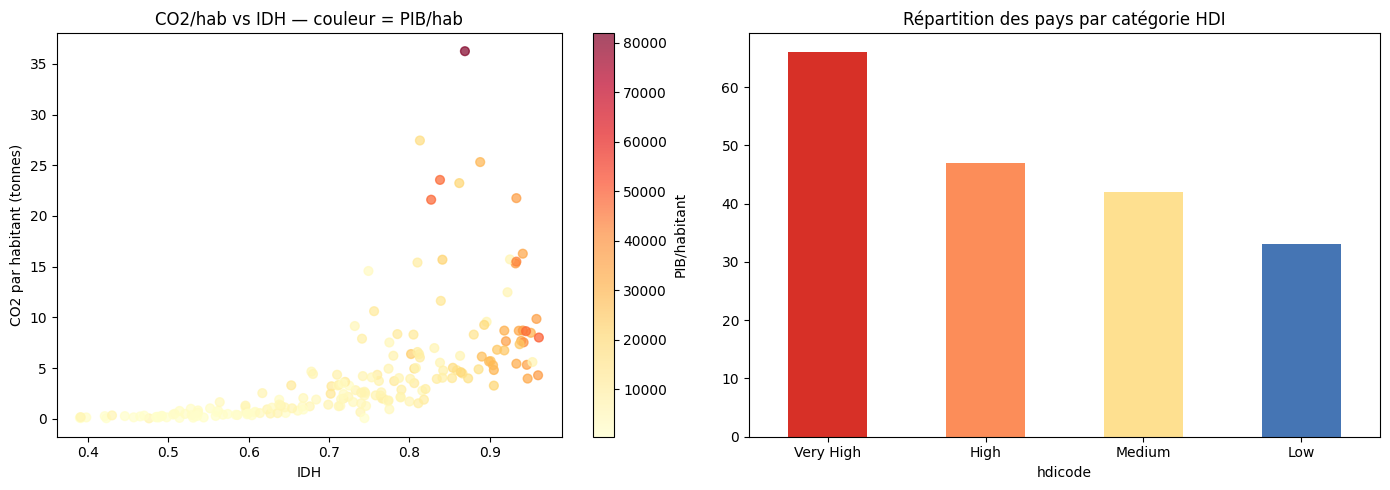


Répartition HDI :
hdicode
Very High    66
High         47
Medium       42
Low          33
Name: count, dtype: int64

Nombre de pays final : 189


In [ ]:
# Variables disponibles — on adapte
vars_cles = ['co2_per_capita', 'hdi', 'gdpPercap',
             'energy_per_capita', 'ghg_per_capita']

print("=== Statistiques descriptives ===")
print(df[vars_cles].describe().round(2))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : CO2/habitant vs IDH
sc = axes[0].scatter(df['hdi'], df['co2_per_capita'],
                     c=df['gdpPercap'], cmap='YlOrRd', alpha=0.7, s=40)
axes[0].set_xlabel('IDH')
axes[0].set_ylabel('CO2 par habitant (tonnes)')
axes[0].set_title('CO2/hab vs IDH — couleur = PIB/hab')
plt.colorbar(sc, ax=axes[0], label='PIB/habitant')

# Plot 2 : Répartition des catégories HDI
df['hdicode'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#d73027','#fc8d59','#fee090','#4575b4'])
axes[1].set_title('Répartition des pays par catégorie HDI')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"\nRépartition HDI :\n{df['hdicode'].value_counts()}")
print(f"\nNombre de pays final : {df['country'].nunique()}")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Variables numériques pour l'ACP

features = ['co2_per_capita', 'co2', 'coal_co2', 'oil_co2', 'gas_co2',
            'cumulative_co2', 'ghg_per_capita', 'energy_per_capita',
            'hdi', 'gdpPercap', 'lifeExp']

X = df[features].copy()

# Standardisation  avant ACP
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Matrice : {X_scaled.shape}")
print(f"Moyenne après scaling : {X_scaled.mean(axis=0).round(3)}")
print(f"Écart-type après scaling : {X_scaled.std(axis=0).round(3)}")

Matrice : (189, 11)
Moyenne après scaling : [-0. -0. -0. -0. -0.  0. -0. -0. -0.  0. -0.]
Écart-type après scaling : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


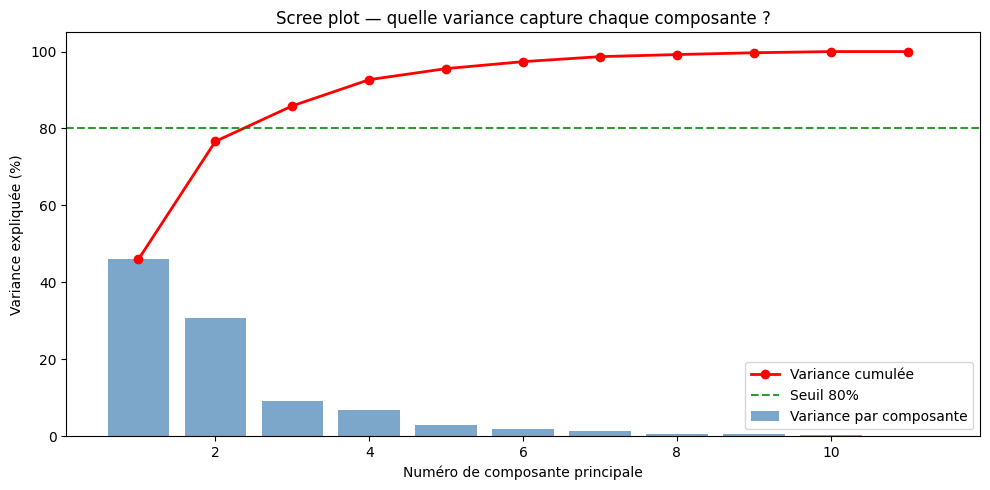

=== Variance expliquée par composante ===
  PC1 : 46.0%  (cumulé : 46.0%)
  PC2 : 30.7%  (cumulé : 76.7%)
  PC3 : 9.2%  (cumulé : 85.9%)
  PC4 : 6.8%  (cumulé : 92.7%)
  PC5 : 2.9%  (cumulé : 95.6%)
  PC6 : 1.8%  (cumulé : 97.4%)

→ 3 composantes suffisent pour 80% de la variance


In [ ]:
# On calcule toutes les composantes pour voir combien sont utiles
pca_full = PCA()
pca_full.fit(X_scaled)

variance_exp = pca_full.explained_variance_ratio_
variance_cum = np.cumsum(variance_exp)

# graphique du coude
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(range(1, len(variance_exp)+1), variance_exp * 100,
              color='steelblue', alpha=0.7, label='Variance par composante')
ax.plot(range(1, len(variance_exp)+1), variance_cum * 100,
        'ro-', linewidth=2, markersize=6, label='Variance cumulée')
ax.axhline(y=80, color='green', linestyle='--', alpha=0.8, label='Seuil 80%')

ax.set_xlabel('Numéro de composante principale')
ax.set_ylabel('Variance expliquée (%)')
ax.set_title('Scree plot — quelle variance capture chaque composante ?')
ax.legend()
plt.tight_layout()
plt.show()

# Résumé chiffré
print("=== Variance expliquée par composante ===")
for i in range(6):
    print(f"  PC{i+1} : {variance_exp[i]*100:.1f}%  "
          f"(cumulé : {variance_cum[i]*100:.1f}%)")

n_comp = np.argmax(variance_cum >= 0.80) + 1
print(f"\n→ {n_comp} composantes suffisent pour 80% de la variance")

In [ ]:
# On garde 3 composantes
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Ajout des coordonnées dans le dataframe
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]
df['PC3'] = X_pca[:, 2]

print("=== ACP avec 3 composantes ===")
for i in range(3):
    print(f"  PC{i+1} : {pca.explained_variance_ratio_[i]*100:.1f}%")
print(f"  Total : {pca.explained_variance_ratio_.sum()*100:.1f}%")

=== ACP avec 3 composantes ===
  PC1 : 46.0%
  PC2 : 30.7%
  PC3 : 9.2%
  Total : 85.9%


=== Loadings — comment lire ce tableau ===
Valeur proche de +1 : variable très corrélée positivement avec la composante
Valeur proche de -1 : variable très corrélée négativement
Valeur proche de 0  : variable peu influente sur cette composante

                   PC1   PC2   PC3
co2_per_capita    0.33 -0.28 -0.34
co2               0.29  0.37  0.02
coal_co2          0.22  0.34  0.04
oil_co2           0.33  0.34 -0.00
gas_co2           0.33  0.27 -0.07
cumulative_co2    0.33  0.32  0.01
ghg_per_capita    0.29 -0.27 -0.44
energy_per_capita 0.32 -0.31 -0.21
hdi               0.29 -0.26  0.46
gdpPercap         0.32 -0.29  0.07
lifeExp           0.24 -0.22  0.65


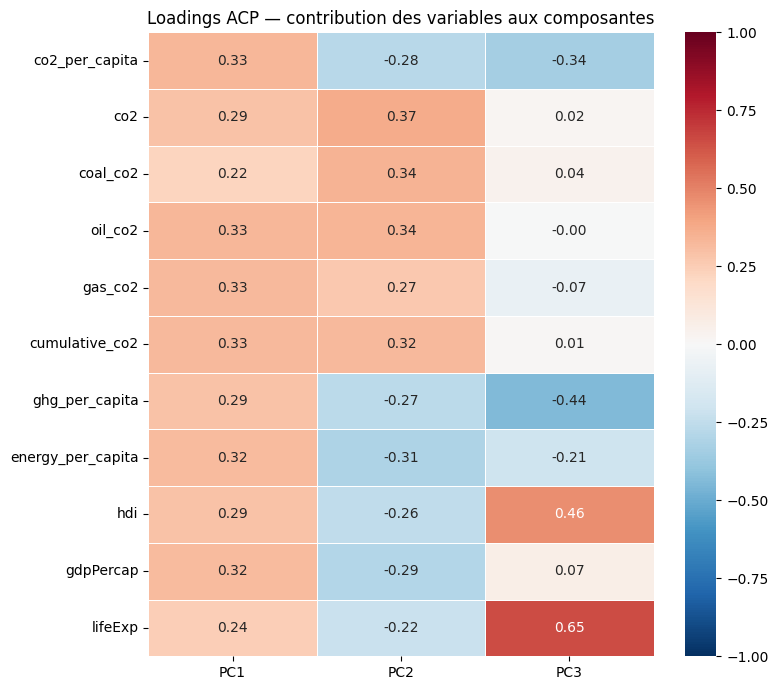

In [ ]:
# Loadings = contribution de chaque variable originale à chaque PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2', 'PC3']
).round(3)

print("=== Loadings — comment lire ce tableau ===")
print("Valeur proche de +1 : variable très corrélée positivement avec la composante")
print("Valeur proche de -1 : variable très corrélée négativement")
print("Valeur proche de 0  : variable peu influente sur cette composante\n")
print(loadings)

# Heatmap des loadings
plt.figure(figsize=(8, 7))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Loadings ACP — contribution des variables aux composantes')
plt.tight_layout()
plt.show()

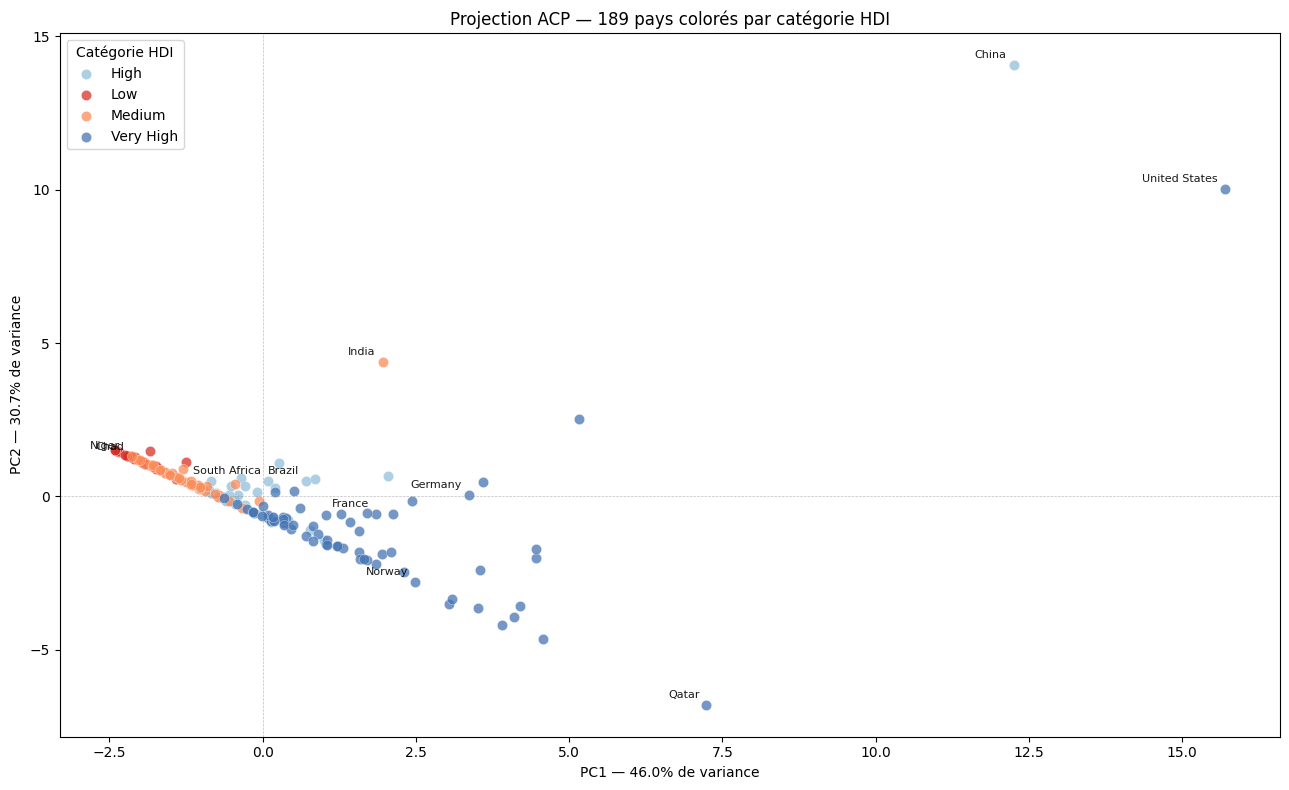

In [ ]:
couleurs = {'Low': '#d73027', 'Medium': '#fc8d59',
            'High': '#91bfdb', 'Very High': '#4575b4'}

fig, ax = plt.subplots(figsize=(13, 8))

for cat, groupe in df.groupby('hdicode'):
    ax.scatter(groupe['PC1'], groupe['PC2'],
               label=cat, color=couleurs[cat],
               alpha=0.75, s=55, edgecolors='white', linewidths=0.3)

# Annotation de pays clés pour l'interprétation
pays_labels = ['Qatar', 'United States', 'China', 'India',
               'Chad', 'Niger', 'Germany', 'France',
               'Brazil', 'South Africa', 'Norway']

for _, row in df[df['country'].isin(pays_labels)].iterrows():
    ax.annotate(row['country'], (row['PC1'], row['PC2']),
                fontsize=8, ha='right', alpha=0.9,
                xytext=(-5, 5), textcoords='offset points')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_xlabel(f"PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% de variance")
ax.set_ylabel(f"PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% de variance")
ax.set_title('Projection ACP — 189 pays colorés par catégorie HDI')
ax.legend(title='Catégorie HDI', loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import NMF

# Variables de consommation énergétique — toutes positives

features_nmf = ['co2_per_capita', 'coal_co2', 'oil_co2',
                'gas_co2', 'cumulative_co2', 'energy_per_capita']

X_nmf = df[features_nmf].copy()

# Vérification
print(f"Valeurs négatives : {(X_nmf < 0).sum().sum()}")
print(f"Shape : {X_nmf.shape}")

# Normalisation Min-Max
from sklearn.preprocessing import MinMaxScaler
scaler_nmf = MinMaxScaler()
X_nmf_scaled = scaler_nmf.fit_transform(X_nmf)

print(f"Min après scaling : {X_nmf_scaled.min():.3f}  (doit être 0)")
print(f"Max après scaling : {X_nmf_scaled.max():.3f}  (doit être 1)")

Valeurs négatives : 0
Shape : (189, 6)
Min après scaling : 0.000  (doit être 0)
Max après scaling : 1.000  (doit être 1)


k=2 → erreur de reconstruction = 1.2075
k=3 → erreur de reconstruction = 0.8619
k=4 → erreur de reconstruction = 0.3749
k=5 → erreur de reconstruction = 0.2377
k=6 → erreur de reconstruction = 0.0105
k=7 → erreur de reconstruction = 0.0139
k=8 → erreur de reconstruction = 0.0117


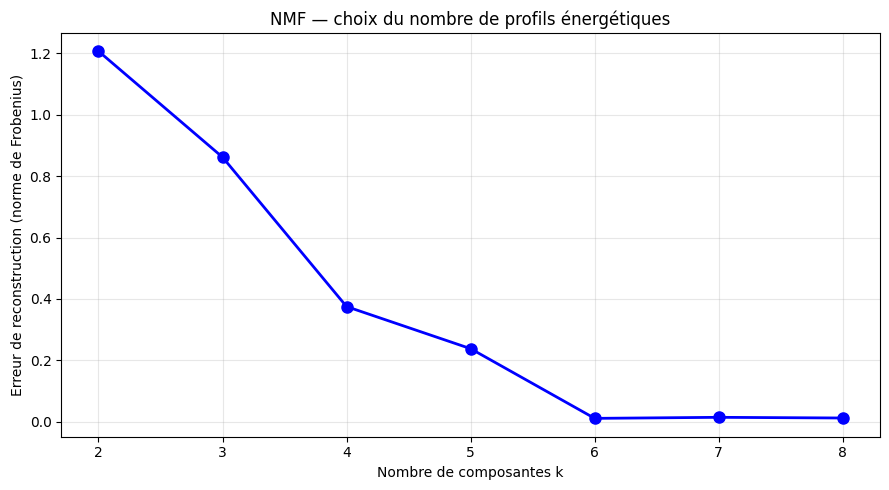

In [ ]:
# On teste k de 2 à 8 et on regarde l'erreur de reconstruction
erreurs = []
valeurs_k = range(2, 9)

for k in valeurs_k:
    nmf_test = NMF(n_components=k, random_state=42, max_iter=500)
    W = nmf_test.fit_transform(X_nmf_scaled)
    # Erreur de Frobenius : ||X - WH||
    erreur = nmf_test.reconstruction_err_
    erreurs.append(erreur)
    print(f"k={k} → erreur de reconstruction = {erreur:.4f}")

# Graphique du coude
plt.figure(figsize=(9, 5))
plt.plot(valeurs_k, erreurs, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Nombre de composantes k')
plt.ylabel('Erreur de reconstruction (norme de Frobenius)')
plt.title('NMF — choix du nombre de profils énergétiques')
plt.grid(alpha=0.3)
plt.xticks(valeurs_k)
plt.tight_layout()
plt.show()

Erreur finale : 0.0105

W (coefficients pays) : (189, 6)  → un score par profil pour chaque pays
H (profils)           : (6, 6)  → contribution de chaque variable à chaque profil


<Figure size 1100x500 with 0 Axes>

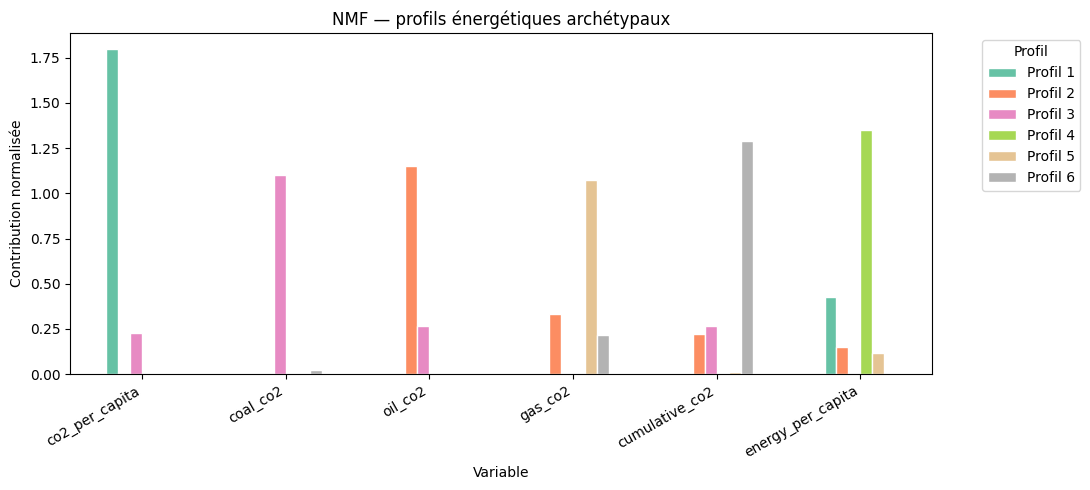


=== Pays les plus représentatifs de chaque profil ===

Profil 1 :
            country  profil_1
              Qatar      0.56
Trinidad and Tobago      0.42
            Bahrain      0.39

Profil 2 :
      country  profil_2
United States      0.84
        China      0.38
        India      0.21

Profil 3 :
      country  profil_3
        China      0.90
        India      0.20
United States      0.11

Profil 4 :
  country  profil_4
  Iceland      0.57
Singapore      0.57
    Qatar      0.56

Profil 5 :
      country  profil_5
United States      0.55
       Russia      0.38
         Iran      0.21

Profil 6 :
      country  profil_6
United States      0.60
       Russia      0.18
        China      0.17


In [ ]:

K_OPTIMAL = 6

nmf = NMF(n_components=K_OPTIMAL, random_state=42, max_iter=500)
W = nmf.fit_transform(X_nmf_scaled)
H = nmf.components_

print(f"Erreur finale : {nmf.reconstruction_err_:.4f}")
print(f"\nW (coefficients pays) : {W.shape}  → un score par profil pour chaque pays")
print(f"H (profils)           : {H.shape}  → contribution de chaque variable à chaque profil")

# Visualisation des profils
profils_df = pd.DataFrame(H, columns=features_nmf,
                          index=[f'Profil {i+1}' for i in range(K_OPTIMAL)])

plt.figure(figsize=(11, 5))
profils_df.T.plot(kind='bar', figsize=(11, 5), colormap='Set2', edgecolor='white')
plt.title('NMF — profils énergétiques archétypaux')
plt.xlabel('Variable')
plt.ylabel('Contribution normalisée')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Profil', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Quel pays représente le mieux chaque profil?
df_nmf = df.copy()
for i in range(K_OPTIMAL):
    df_nmf[f'profil_{i+1}'] = W[:, i]

print("\n=== Pays les plus représentatifs de chaque profil ===")
for i in range(K_OPTIMAL):
    top3 = df_nmf.nlargest(3, f'profil_{i+1}')[['country', f'profil_{i+1}']]
    print(f"\nProfil {i+1} :")
    print(top3.to_string(index=False))